Jio Customer Churn Analysis

Step 1 : First, we load the dataset and perform an initial inspection to identify missing values and data type inconsistencies.

In [ ]:
# Imported Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

In [ ]:
# Load the dataset
df = pd.read_csv('/content/Customer Churn.csv')

In [ ]:
# DATA INSPECTION
print("First 5 rows of the dataset:")
display(df.head())

print("\nDataset Info (checking for nulls and data types):")
df.info()

First 5 rows of the dataset:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes



Dataset Info (checking for nulls and data types):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   obje

Step 2 : Data Cleaning

So very first step is in TotalCharges we have some blank values so we'll replace with 0. After replacing when we run df.info so in that we can see data type is changed.

In [ ]:
# We convert to numeric first (errors become NaN), then fill NaN with 0.
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [ ]:
df['TotalCharges'] = df['TotalCharges'].fillna(0.0)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [ ]:
# Remove 'customerID' as Unique IDs have no predictive power for the model.
df.drop(columns=['customerID'], inplace=True)

In [ ]:
# In senior citizen column we are replacing 0 with no and 1 with yes because it would be easy for EDA process.
df['SeniorCitizen'] = df['SeniorCitizen'].map({0: 'No', 1: 'Yes'})

Final Data Check

In [ ]:
display(df.head())
df.info()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,No,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,No,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,No,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,No,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   object 
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


Step 3 : Exploratory Data Analysis (EDA)

--> Descriptive Analytics (What is happening?)
We start by understanding the overall Churn rate and the distribution of our numerical variables.

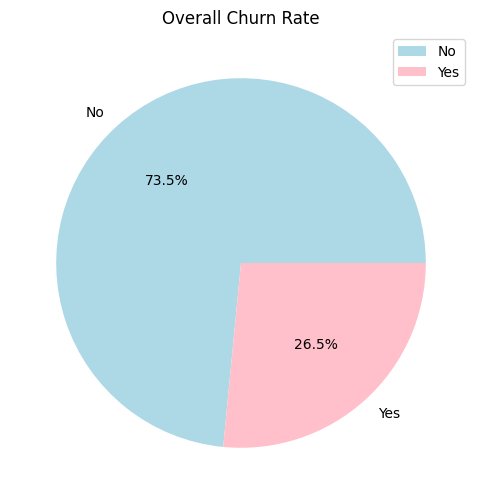

In [ ]:
# 1. Target Variable: Churn Distribution (Pie Chart)
# We want to see the percentage of customers who left (Yes) vs. stayed (No)

plt.figure(figsize=(6, 6))

# Count the number of 'Yes' and 'No' in the Churn column
churn_counts = df['Churn'].value_counts()

# Create the pie chart
plt.pie(churn_counts,
        labels=churn_counts.index,   # Labels: 'Yes', 'No'
        autopct='%1.1f%%',           # Show percentage with 1 decimal place
        colors=['#ADD8E6', '#FFC0CB']) # Blue for No, Red for Yes

plt.title('Overall Churn Rate')
plt.legend()
plt.show()

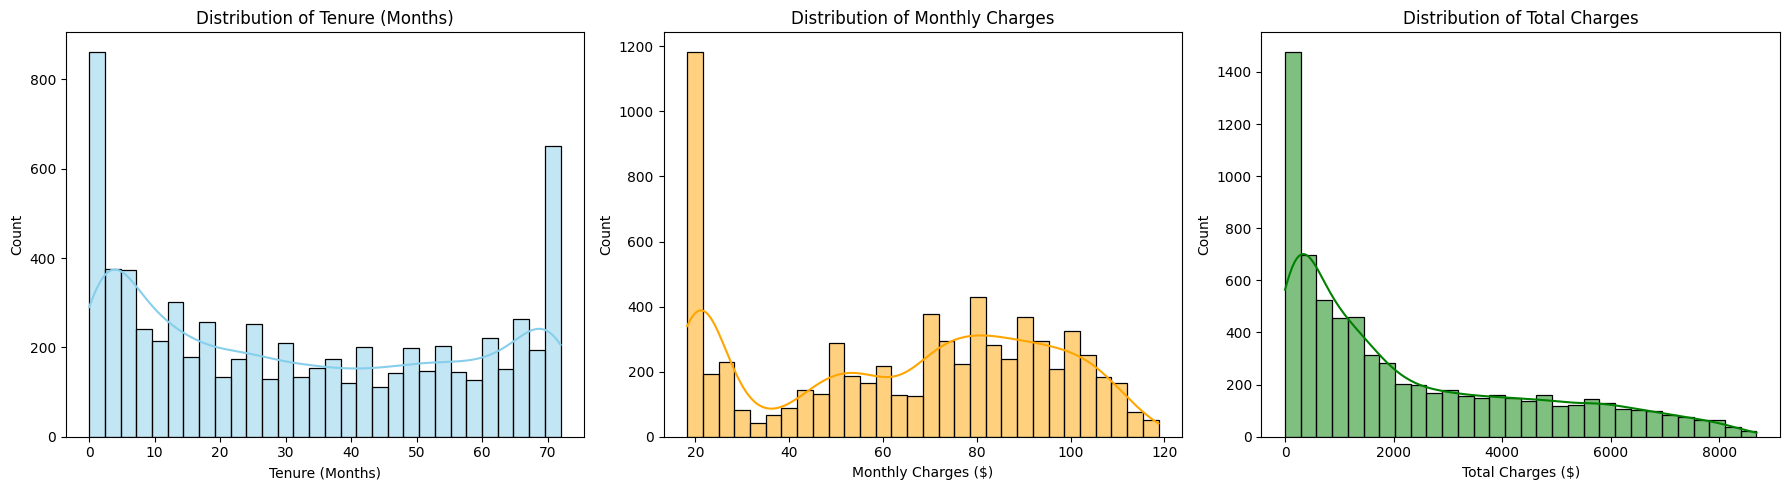

In [ ]:
# 2. Numerical Distributions
# We want to see the spread of Tenure and Both Charges.
# We create a figure with 3 small charts side-by-side
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Chart 1: Tenure (How long have they been customers?)
# 'kde=True' adds the smooth curve line over the bars
sns.histplot(df['tenure'], bins=30, kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Distribution of Tenure (Months)')
axes[0].set_xlabel('Tenure (Months)')

# Chart 2: Monthly Charges (How much do they pay monthly?)
sns.histplot(df['MonthlyCharges'], bins=30, kde=True, ax=axes[1], color='orange')
axes[1].set_title('Distribution of Monthly Charges')
axes[1].set_xlabel('Monthly Charges ($)')

# Chart 3: Total Charges (How much have they paid in total?)
sns.histplot(df['TotalCharges'], bins=30, kde=True, ax=axes[2], color='green')
axes[2].set_title('Distribution of Total Charges')
axes[2].set_xlabel('Total Charges ($)')

plt.tight_layout()
plt.show()

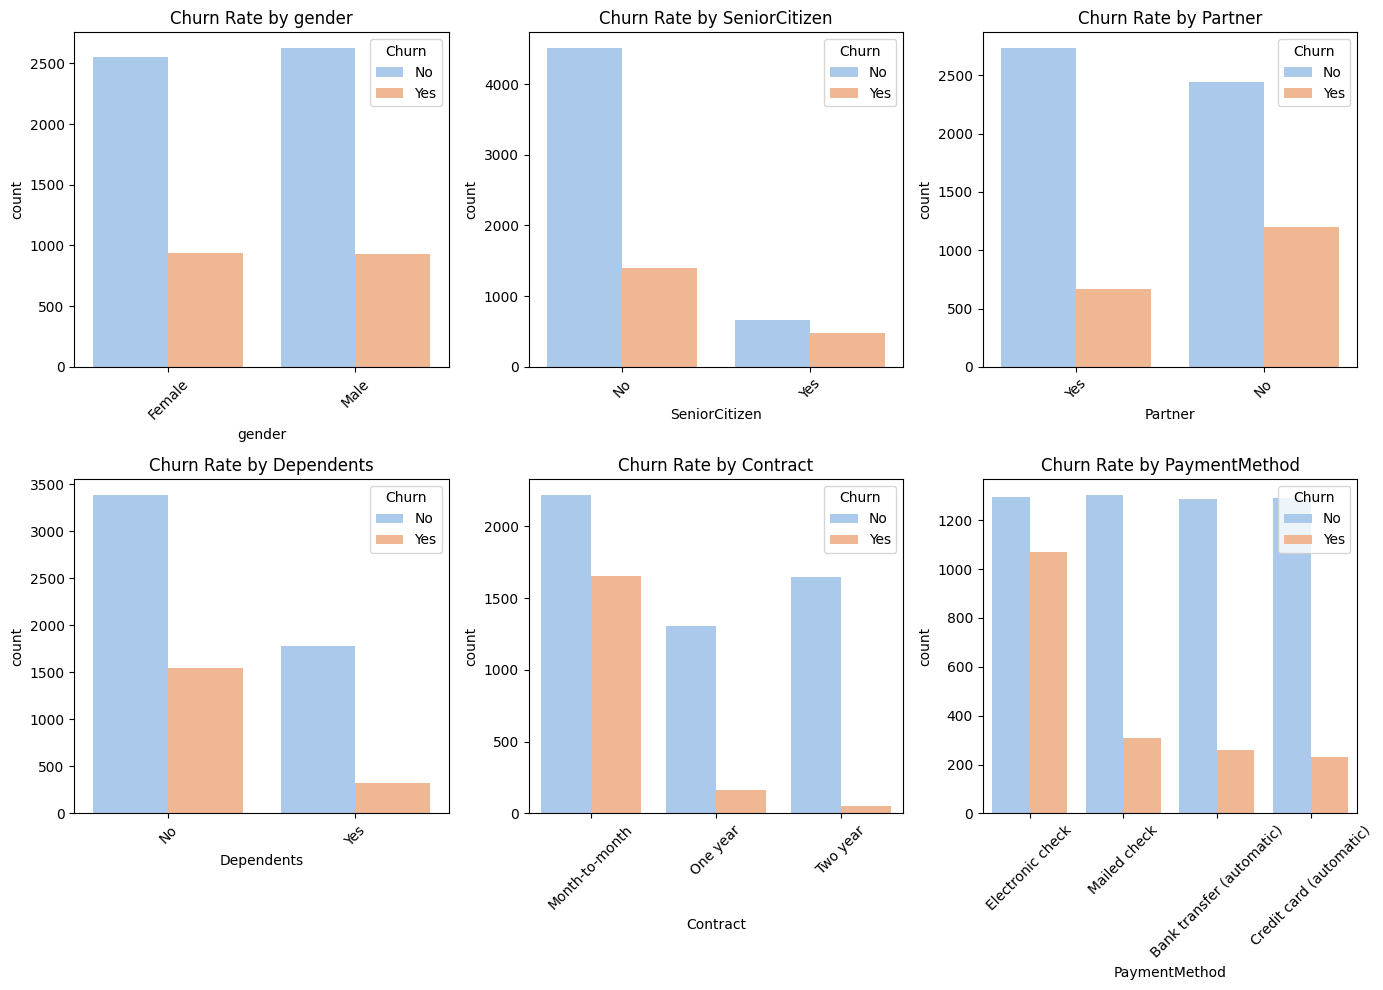

In [ ]:
# DIAGNOSTIC ANALYTICS
# 1. Categorical Variables vs Churn (Bar Chart)

# List of columns we want to check
cols = ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'Contract', 'PaymentMethod']

plt.figure(figsize=(14, 10)) # Create a large canvas

# Loop through each column and create a chart
for i, col in enumerate(cols, 1):
    plt.subplot(2, 3, i)
    sns.countplot(x=col, hue='Churn', data=df, palette='pastel')

    plt.title(f'Churn Rate by {col}')
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

/tmp/ipython-input-1818094291.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y='tenure', data=df, palette='Set2')
/tmp/ipython-input-1818094291.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y='MonthlyCharges', data=df, palette='Set2')


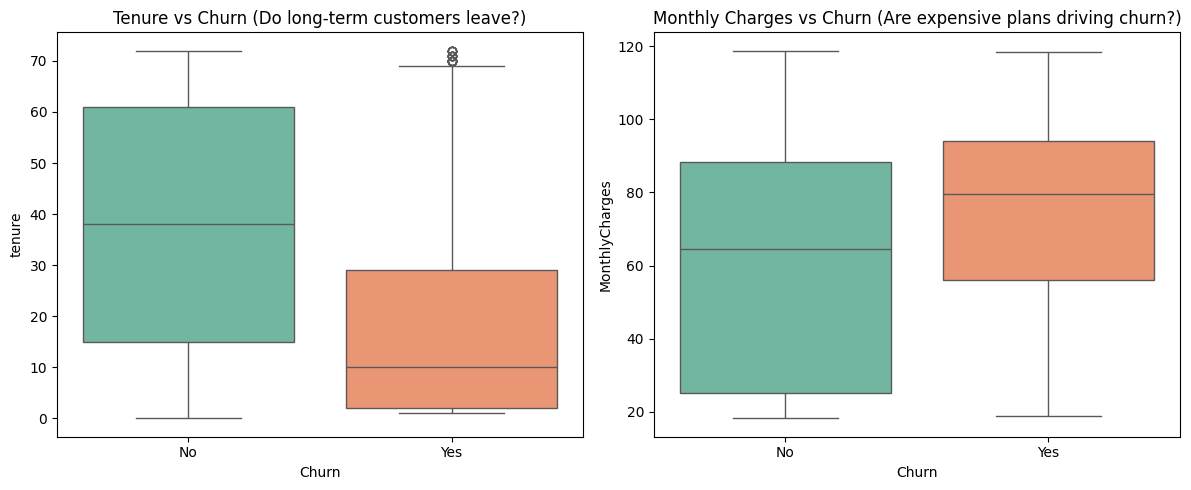

In [ ]:
# 2. Numerical Variables vs Churn (Boxplot)

plt.figure(figsize=(12, 5))

# Chart 1: Tenure vs Churn
# Question: Do people who leave usually have lower tenure?
plt.subplot(1, 2, 1)
sns.boxplot(x='Churn', y='tenure', data=df, palette='Set2')
plt.title('Tenure vs Churn (Do long-term customers leave?)')

# Chart 2: Monthly Charges vs Churn
# Question: Do people who leave usually pay higher monthly bills?
plt.subplot(1, 2, 2)
sns.boxplot(x='Churn', y='MonthlyCharges', data=df, palette='Set2')
plt.title('Monthly Charges vs Churn (Are expensive plans driving churn?)')

plt.tight_layout()
plt.show()

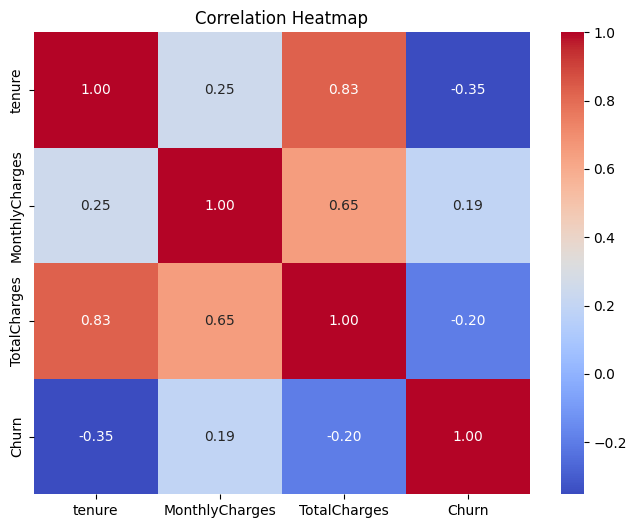

In [ ]:
# 3. Correlation Matrix (Heatmap)
# Computers only understand numbers, so we must convert "Yes/No" to 1/0 in churn column.

df_corr = df.copy()

# Convert 'Churn' from Yes/No to 1/0
df_corr['Churn'] = df_corr['Churn'].map({'Yes': 1, 'No': 0})

# Select only the columns that are numbers (float or int)
numeric_df = df_corr.select_dtypes(include=['float64', 'int64'])

# Create the Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(numeric_df.corr(),
            annot=True,
            cmap='coolwarm',   # Red = Positive correlation, Blue = Negative
            fmt=".2f")         # Show 2 decimal places

plt.title('Correlation Heatmap')
plt.show()

In [ ]:
# Predictive Analytics

# Create a copy of the dataframe for modeling
df_model = df.copy()

# Drop customerID as it is just an ID and has no predictive power
if 'customerID' in df_model.columns:
    df_model = df_model.drop('customerID', axis=1)

# Encode the target variable 'Churn' (Yes -> 1, No -> 0)
le = LabelEncoder()
df_model['Churn'] = le.fit_transform(df_model['Churn'])

# Convert all other categorical variables into numeric (One-Hot Encoding)
# This turns columns like 'Gender' into 'Gender_Male' (0 or 1)
df_model = pd.get_dummies(df_model, drop_first=True)

In [ ]:
df_model.head()

,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,SeniorCitizen_Yes,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,1,29.85,29.85,0,False,False,True,False,False,True,...,False,False,False,False,False,False,True,False,True,False
1,34,56.95,1889.50,0,True,False,False,False,True,False,...,False,False,False,False,True,False,False,False,False,True
2,2,53.85,108.15,1,True,False,False,False,True,False,...,False,False,False,False,False,False,True,False,False,True
3,45,42.30,1840.75,0,True,False,False,False,False,True,...,False,False,False,False,True,False,False,False,False,False
4,2,70.70,151.65,1,False,False,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False


In [ ]:
#2. Splitting the Data

# X contains all the features (predictors)
X = df_model.drop('Churn', axis=1)
# y contains the target (what we want to predict)
y = df_model['Churn']

# Split: 80% for training, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# --- 3. Feature Scaling ---
# This ensures that 'Tenure' (0-72) and 'MonthlyCharges' (20-120) are treated equally
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
#4. Model Training & Prediction

# Model A: Logistic Regression
log_reg = LogisticRegression(random_state=42)
log_reg.fit(X_train, y_train)
y_pred_log = log_reg.predict(X_test)

# Model B: Random Forest Classifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

In [ ]:
#5. Evaluation

def print_score(y_test, y_pred, model_name):
    print(f"--- {model_name} Results ---")
    print(f"Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
    print(f"Precision: {precision_score(y_test, y_pred):.4f}")
    print(f"Recall:    {recall_score(y_test, y_pred):.4f}")
    print(f"F1 Score:  {f1_score(y_test, y_pred):.4f}")
    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    print("-" * 30)

print_score(y_test, y_pred_log, "Logistic Regression")
print_score(y_test, y_pred_rf, "Random Forest")

--- Logistic Regression Results ---
Accuracy:  0.8204
Precision: 0.6852
Recall:    0.5952
F1 Score:  0.6370

Confusion Matrix:
[[934 102]
 [151 222]]
------------------------------
--- Random Forest Results ---
Accuracy:  0.7956
Precision: 0.6592
Recall:    0.4718
F1 Score:  0.5500

Confusion Matrix:
[[945  91]
 [197 176]]
------------------------------


In [ ]:
# STEP 5: IMPROVING THE MODEL WITH SMOTE

# Note: If you get an error saying 'No module named imblearn',
# uncomment the line below and run it once, then comment it out again.
# !pip install imbalanced-learn

from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression

# 1. Initialize SMOTE
# We set a random_state so the results are reproducible
smote = SMOTE(random_state=42)

# 2. Resample the Training Data ONLY
# (We use the X_train that you already scaled in the previous step)
print(f"Original Training Churn Counts: {y_train.value_counts()}")
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)
print(f"Resampled Training Churn Counts: {y_train_resampled.value_counts()}")

# 3. Train a NEW Logistic Regression on the Balanced Data
log_reg_smote = LogisticRegression(random_state=42)
log_reg_smote.fit(X_train_resampled, y_train_resampled)

# 4. Predict on the Original Test Set
y_pred_smote = log_reg_smote.predict(X_test)

# 5. Evaluate results
print("-" * 30)
print("--- Logistic Regression (with SMOTE) ---")
print("-" * 30)
# We use the print_score function you defined earlier
print_score(y_test, y_pred_smote, "SMOTE Model")

Original Training Churn Counts: Churn
0    4138
1    1496
Name: count, dtype: int64
Resampled Training Churn Counts: Churn
0    4138
1    4138
Name: count, dtype: int64
------------------------------
--- Logistic Regression (with SMOTE) ---
------------------------------
--- SMOTE Model Results ---
Accuracy:  0.7644
Precision: 0.5421
Recall:    0.7078
F1 Score:  0.6140

Confusion Matrix:
[[813 223]
 [109 264]]
------------------------------


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


### Conclusion & Recommendations

### Key Findings
* **High Risk Customers:** Users on **Month-to-Month contracts**, paying via **Electronic Check**, with **high monthly charges** are the most likely to leave.
* **Tenure:** Churn is highest in the first 12 months.

### Business Recommendations
1.  **Contract Push:** Offer incentives for month-to-month users to switch to 1-year or 2-year contracts.
2.  **Payment Update:** Give a discount for switching from Electronic Check to AutoPay (Credit Card).
3.  **Targeted Retention:** Use this model to identify "high-risk" customers and offer them special deals *before* they cancel the plan.